# Pràctica de Classificació amb la base de dades "Breast Cancer (sklearn)"

## Objectius de la pràctica

- Treballar amb la base de dades **Breast Cancer Wisconsin Diagnostic** (sklearn).
- Entendre les propietats de les variables observades i com es relacionen amb el diagnòstic de càncer (benigne/maligne).
- Explicar com les variables observades poden indicar risc de malignitat.
- Crear un predictor del diagnòstic (classificador de tumors de mama).
- Aprendre a fer **Exploratory Data Analysis (EDA)**, per entendre la base de dades i el problema a resoldre.
- Resoldre el problema fent servir una tècnica simple i intuïtiva de classificació (per exemple, **Random Forest**).


## 1. Descripció del problema

**Objectiu**

Estudi sobre el diagnòstic de tumors de mama (breast cancer) a partir de mesures obtingudes d'imatges de biòpsies de tumors. L'objectiu és predir si el tumor és **Maligne** o **Benigne** a partir de característiques morfològiques de les cèl·lules.

**Especificacions**

- Estudiar la composició de la base de dades.
- Entendre la relació entre les mesures i el diagnòstic.
- Veure la distribució de les variables i com les seves estadístiques es relacionen amb major o menor risc.
- Analitzar el predictor resultant, per entendre com s'explica el diagnòstic.




# Breast Cancer Wisconsin (Diagnostic) – Descripció de la base de dades

## Descripció

La base de dades **Breast Cancer Wisconsin (Diagnostic)** ( **WDBC**) és un conjunt de dades  en l’àmbit de l’aprenentatge automàtic. Va ser creada pel **Dr. William H. Wolberg**, **W. Nick Street** i **Olvi L. Mangasarian** a l’Hospital de la Universitat de Wisconsin, Madison, i es va incorporar al UCI Machine Learning Repository l’any 1995.

El conjunt de dades conté **569 casos** (pacients) i **30 variables numèriques** calculades a partir d’imatges digitalitzades de mostres de **punció aspirativa amb agulla fina (FNA)** de masses mamàries. Cada variable descriu característiques dels nuclis cel·lulars visibles a la imatge. La variable objectiu indica si el tumor és **Maligne (M)** o **Benigne (B)**.

| Propietat             | Valor                     |
|-----------------------|---------------------------|
| Nombre d’instàncies   | 569                       |
| Nombre de variables   | 30 (totes numèriques)     |
| Nombre de classes     | 2 (Maligne = 212, Benigne = 357) |
| Valors perduts        | Cap                       |

---

## Variables

Per cadascuna de les **10 mesures bàsiques**, es calculen tres estadístics sobre tots els nuclis de la imatge: **mitjana (mean)**, **error estàndard (se)** i **pitjor valor (worst)** (mitjana dels tres valors més grans). Això dona lloc a **30 característiques** en total.

### Mesures bàsiques

| Variable              | Descripció |
|-----------------------|-----------|
| **radius**            | Mitjana de les distàncies des del centre del nucli fins als punts del perímetre. |
| **texture**           | Desviació estàndard dels nivells de grisos a la regió del nucli. |
| **perimeter**         | Longitud del perímetre del nucli. |
| **area**              | Àrea del nucli. |
| **smoothness**        | Variació local en la longitud del radi (mesura de la regularitat del contorn). |
| **compactness**       | Definida com $perimeter^2 / area- 1$. Valors alts indiquen formes més irregulars. |
| **concavity**         | Severitat de les parts còncaves del contorn. |
| **concave points**    | Nombre de punts còncavs al contorn. |
| **symmetry**          | Simetria de la forma del nucli. |
| **fractal dimension** | Aproximació del tipus “línia de costa” menys 1; captura la complexitat del contorn a diferents escales. |

### Llista completa de les 30 característiques

| #  | Nom de la variable            | Tipus d’estadístic |
|----|-------------------------------|--------------------|
| 1  | mean radius                   | mitjana            |
| 2  | mean texture                  | mitjana            |
| 3  | mean perimeter                | mitjana            |
| 4  | mean area                     | mitjana            |
| 5  | mean smoothness               | mitjana            |
| 6  | mean compactness              | mitjana            |
| 7  | mean concavity                | mitjana            |
| 8  | mean concave points           | mitjana            |
| 9  | mean symmetry                 | mitjana            |
| 10 | mean fractal dimension        | mitjana            |
| 11 | radius error                  | error estàndard    |
| 12 | texture error                 | error estàndard    |
| 13 | perimeter error               | error estàndard    |
| 14 | area error                    | error estàndard    |
| 15 | smoothness error              | error estàndard    |
| 16 | compactness error             | error estàndard    |
| 17 | concavity error               | error estàndard    |
| 18 | concave points error          | error estàndard    |
| 19 | symmetry error                | error estàndard    |
| 20 | fractal dimension error       | error estàndard    |
| 21 | worst radius                  | pitjor valor       |
| 22 | worst texture                 | pitjor valor       |
| 23 | worst perimeter               | pitjor valor       |
| 24 | worst area                    | pitjor valor       |
| 25 | worst smoothness              | pitjor valor       |
| 26 | worst compactness             | pitjor valor       |
| 27 | worst concavity               | pitjor valor       |
| 28 | worst concave points          | pitjor valor       |
| 29 | worst symmetry                | pitjor valor       |
| 30 | worst fractal dimension       | pitjor valor       |

### Variable objectiu

| Valor | Etiqueta  |
|-------|-----------|
| 0     | Maligne   |
| 1     | Benigne   |

---

## Bibliografia

1. **Wolberg, W. H., Street, W. N., & Mangasarian, O. L. (1995).**  
   *Breast Cancer Wisconsin (Diagnostic) Data Set.*  
   UCI Machine Learning Repository.  

2. **Street, W. N., Wolberg, W. H., & Mangasarian, O. L. (1993).**  
   *Nuclear Feature Extraction for Breast Tumor Diagnosis.*  
   IS&T/SPIE 1993 International Symposium on Electronic Imaging: Science and Technology, San Jose, CA, Vol. 1905, pp. 861–870.  

3. **Mangasarian, O. L., Street, W. N., & Wolberg, W. H. (1995).**  
   *Breast Cancer Diagnosis and Prognosis Via Linear Programming.*  
   Operations Research, 43(4), 570–577.  

### 1.1. Càrrega de dades i definició de variables


In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


data = load_breast_cancer()
X = pd.DataFrame(data=data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")  # 0 = malignant, 1 = benign

df = X.copy()
df["target"] = y
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


**1.1. Variables de la base de dades**

La base de dades conté 30 variables numèriques derivades de l'anàlisi d'imatges de nuclis cel·lulars en biòpsies de tumors de mama. Cada variable descriu una mesura de forma o textura (per exemple: radi, textura, perímetre, àrea, suavitat, etc.).

- `target`: Etiqueta de classe (0 = malignant, 1 = benign).
- Per a cada atribut (p. ex. `radius`, `texture`, `perimeter`, `area`, `smoothness`, `compactness`, `concavity`, `concave points`, `symmetry`, `fractal dimension`), hi ha tres variants:
  - `mean` (mitjana sobre el nucli)
  - `se` (error estàndard)
  - `worst` (pitjor/valor màxim)

Per exemple:
- `mean radius`: radi mitjà del nucli.
- `mean texture`: variació de la intensitat de grisos.
- `worst area`: àrea màxima observada.


In [2]:
X.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='object')

**Exercici 1**

- Per tal de clarificar els objectius d'aquesta pràctica, redactar un paràgraf resumint el tipus de base de dades utilitzada i l'objectiu de la pràctica.

En aquesta pràctica utiliztem la base de dades "Breast Cancer Wisconsin", la qual té diferents vaiables que recullen informació de diferents tumors, que s'ha conseguit a partir d'imatges. L'objectiu de la pràctica es intentar predir si un tumor és maligne o benigne.

- A partir del nom de les variables (`radius`, `texture`, `perimeter`, `area`, `smoothness`, `compactness`, `concavity`, `concave points`, `symmetry`, `fractal dimension`), escrigui breument quines creu que poden estar associades a un major risc de malignitat. Faci una frase d’una línia per justificar cada cas.

(Com normalment diu el profe, això ho deixem. Ja hem reflexionat sobre això durant l'explicació de la pràctica).



## 2. Random Forest: una introducció intuïtiva

En aquesta secció veurem **Random Forest** com una extensió natural dels arbres de decisió, pensada per reduir variància, controlar el biaix i obtenir una millor estimació de l’error de test.

---

### 2.1. Per què agregar molts arbres? Variància i biaix

Un **arbre de decisió profund** és un model molt flexible: pot adaptar-se gairebé perfectament a les dades d’entrenament. Això implica:

- **Biaix baix**: pot representar fronteres de decisió molt complexes, seguint bé els patrons de les dades.
- **Variància alta**: petits canvis en les dades (afegir/eliminar pocs exemples) poden canviar molt l’estructura de l’arbre i, per tant, les prediccions.

**Idèia clau del Random Forest**:  
En lloc de construir un sol arbre “molt sorollós”, construïm **molts arbres independents** i **promediem** (classificació: vot majoritari, regressió: mitjana). Això té un efecte geomètric clar:

- Cada arbre parteix l’espai de característiques en regions (hiper-rectangles).
- La combinació de molts particionaments dóna una frontera de decisió més **suau** i **estable**.
- L’**esperança** de la predicció (biaix) canvia poc si tots els arbres són prou flexibles.
- La **variància** es redueix fortament en promig, perquè els errors “aleatoris” de cada arbre es compensen.

En termes de biaix–variància:
- Es manté un **biaix baix** (arbres profunds).
- Es redueix la **variància** gràcies a l’agregació de molts models.

---

### 2.2. Motivació del bootstrapping i del bagging

Si entrenem molts arbres sobre **exactament el mateix conjunt de dades**, tots veuran els mateixos punts i, amb el mateix algoritme i els mateixos paràmetres, tendiran a semblar-se molt. Això vol dir que:

- Les seves errades estaran **altament correlades**.
- Promediar arbres gairebé iguals **no** redueix gaire la variància.

Per evitar-ho, s’introdueix el **bootstrapping**:

- De la mostra original amb $N$ observacions, es generen molts subconjunts d’entrenament escollint **amb reemplaçament** \(N\) observacions (mateixa mida, però amb repeticions).
- Cada subconjunt bootstrap és lleugerament diferent, amb alguns punts repetits i altres absents.

El procediment de formar molts models sobre diferents mostres bootstrap i promediar-los s’anomena **bagging** (bootstrap aggregating):

- Cada arbre veu una **varietat** lleugerament diferent de dades.
- Això fa que les prediccions de cada arbre estiguin menys correlacionades.
- En promig, la variància global baixa de manera significativa.

Geomètricament: cada arbre veu un núvol de punts lleugerament diferent a l’espai de característiques; les fronteres (particions) que construeixen són similars però no idèntiques; el promig d’aquestes fronteres és molt més robust.

---

### 2.3. Com aconseguir arbres amb biaix diferent sobre les mateixes dades

Només amb bootstrapping, els arbres encara poden ser massa semblants, sobretot si hi ha algunes característiques molt dominants. Random Forest introdueix una segona font d’aleatorietat:

- A cada **node** de l’arbre, en lloc de considerar **totes** les variables per trobar la millor partició, es considera només un **subconjunt aleatori de característiques** (per exemple, $\sqrt{p}$ en classificació, on \(p\) és el nombre total de variables).

Això té dos efectes:

1. **Decorrela els arbres**:  
   - Diferents arbres prendran decisions (splits) en dimensions diferents, fins i tot si la mostra bootstrap fos semblant.  
   - Les fronteres de decisió resultants ocupen diferents “direccions” en l’espai de característiques.

2. **Canvia lleugerament el biaix de cada arbre**:  
   - Cada arbre veu un “sub-espai” de característiques en cada node.  
   - Algunes variables molt fortes poden quedar temporalment “excloses”, i l’arbre es veu obligat a utilitzar altres variables per separar les dades.  
   - Això genera arbres amb diferents patrons de decisió, alguns més simples en certes dimensions, d’altres més complexos en altres.

El **Random Forest** és, per tant, una combinació de:

- Bootstrapping (variància baixa i menys correlació per les dades).
- Submostreig de característiques (variància encara més baixa, arbres decorrelats, i lleuger ajustament del biaix).

---

### 2.4. Per què l’error OOB (Out-of-Bag) aprox. l’error de test?

En bootstrapping, cada arbre es construeix a partir d’una mostra amb reemplaçament del conjunt original. Això implica:

- Cada arbre **no veu** aproximadament un ~36% de les observacions originals (probabilitat de quedar fora \(\approx e^{-1}\)).
- Aquestes observacions que **no** s’han utilitzat per construir l’arbre es diuen **Out-of-Bag (OOB)** per a aquell arbre.

Idèia clau:

- Per cada observació concreta \(i\), podem considerar **només els arbres** per als quals \(i\) és OOB (no ha estat al bootstrap d’entrenament).
- Aquest conjunt d’arbres no ha “vist” \(i\) durant l’entrenament, i per tant la seva predicció sobre \(i\) és, en esperit, una **predicció sobre un punt de test**.

Procediment:

1. Per cada observació \(i\), recollim les prediccions de tots els arbres on \(i\) és OOB.
2. Combinen aquestes prediccions (vot majoritari o mitjana) per obtenir una predicció OOB per a \(i\).
3. Compareu aquesta predicció OOB amb l’etiqueta real de \(i\).
4. Repetiu per a totes les observacions i computeu la taxa d’error global OOB.

Això dóna una estimació interna de l’**error de generalització** (error de test), sense necessitat de reservar explícitament un conjunt de test extern. Com que, en mitjana, cada punt és OOB per una quantitat raonable d’arbres, la predicció OOB és una bona aproximació al comportament del bosc sobre dades noves.

Geomètricament: per cada punt, mirem com el “núvol” de fronteres de decisió dels arbres que no l’han vist el situen a l’espai de particions; la proporció d’arbres que el classifiquen correctament és una estimació de com de “segur” està aquest punt en la regió de decisió del bosc.

**Exercici 2**

- Escrigui en dues o tres línies com interpreta la metàfora geomètrica: què vol dir que dues observacions (dos tumors) estiguin "a prop" o "lluny" en aquest espai de 30 dimensions?
- Intenteu explicar per què pot ser difícil separar perfectament els punts malignes i benignes quan es projecten en 2D, però més fàcil en 30D. 

Si dues observacions estan a prop, en 2D haurem de traçar la línea que separi els dos punts en canvi en 30D, tindrem moltes més opcions per tenir-ho més acotat i per tant, ens permetrar se més precisos per la quantitat de variables que tenim, i ens disminueix la probabilitat de tenir mostres poc representatives. 


## 3. Estructura bàsica del DataFrame


In [3]:
print("="*60)
print("📊 ESTRUCTURA BÀSICA DEL DATAFRAME")
print("="*60)
print(f"📈 Nombre total de files (pacients):     {df.shape[0]:>4}")
print(f"📈 Nombre total de columnes (variables): {df.shape[1]:>4}")
print(f"🎯 Variable objectiu:                  {df.columns[-1]}")
print(f"🔢 Variables predictives:              {df.shape[1]-1}")
print("="*60)

print("\n📋 INFORMACIÓ DETALLADA PER COLUMNES:")
print("-" * 60)
df.info()

📊 ESTRUCTURA BÀSICA DEL DATAFRAME
📈 Nombre total de files (pacients):      569
📈 Nombre total de columnes (variables):   31
🎯 Variable objectiu:                  target
🔢 Variables predictives:              30

📋 INFORMACIÓ DETALLADA PER COLUMNES:
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    

**Exercici 3**

- Expliqui breument (dos o tres línies) quina informació proporciona la instrucció `df.shape` i `df.columns`.

df.shape: Ens dona el numero de filas/columnes de una matriu.

df.columns: Ens dona el nom de les capçeleres, com li diem -1, ens dona el de de l'última columna, i per tant el target. 

- (en una linea) Quin avantatge té disposar de totes les variables en format numèric per aplicar mètodes de Machine Learning, comparat amb tenir moltes variables categòriques en format `object`?

Tenir totes les variables en format numèric ens permet aplicar els mètodes molt millor perquè no hem de mapejar les etiquetes i per tant, no introduim un biaix alhora de fer les etiquetes i veiem de manera molt més clara la diferència ja que si tinguessim (bo i molt bo) és ptijor que valors numèrics més fiables.

## 4. Descripció general de les dades (EDA bàsic)

### 4.1. Estadístiques resumides de les variables numèriques


In [4]:
df.describe().round(2)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,...,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10,0.10,0.09,0.05,0.18,0.06,...,25.68,107.26,880.58,0.13,0.25,0.27,0.11,0.29,0.08,0.63
std,3.52,4.30,24.30,351.91,0.01,0.05,0.08,0.04,0.03,0.01,...,6.15,33.60,569.36,0.02,0.16,0.21,0.07,0.06,0.02,0.48
min,6.98,9.71,43.79,143.50,0.05,0.02,0.00,0.00,0.11,0.05,...,12.02,50.41,185.20,0.07,0.03,0.00,0.00,0.16,0.06,0.00
25%,11.70,16.17,75.17,420.30,0.09,0.06,0.03,0.02,0.16,0.06,...,21.08,84.11,515.30,0.12,0.15,0.11,0.06,0.25,0.07,0.00
50%,13.37,18.84,86.24,551.10,0.10,0.09,0.06,0.03,0.18,0.06,...,25.41,97.66,686.50,0.13,0.21,0.23,0.10,0.28,0.08,1.00
75%,15.78,21.80,104.10,782.70,0.11,0.13,0.13,0.07,0.20,0.07,...,29.72,125.40,1084.00,0.15,0.34,0.38,0.16,0.32,0.09,1.00
max,28.11,39.28,188.50,2501.00,0.16,0.35,0.43,0.20,0.30,0.10,...,49.54,251.20,4254.00,0.22,1.06,1.25,0.29,0.66,0.21,1.00


La instrucció `df.describe()` proporciona:

- **count**: nombre de valors no nuls.
- **mean**: mitjana aritmètica.
- **std**: desviació estàndard.
- **min, 25%, 50%, 75%, max**: mínim, quartils i màxim.

Aquesta informació permet obtenir una primera visió general de l’escala de cada variable i detectar eventuals valors extrems.


**Exercici 4**

- Triï dues variables (per exemple, `mean radius` i `mean area`) i descrigui en un parell de línies la informació que proporciona `df.describe()` per aquestes dues variables (rang, mitjana, relació entre mitjana i mediana).
- A partir d’aquests descriptius, com intuïria la forma de la distribució (simètrica, asimètrica, amb cues llargues, etc.)?

MEAN RADIUS: mitjana = 14.13, 50% = 13.37 i std = 3.52 per tant podem veure que més o menys sí que es comporta com a una variable amb distribució normal tot i que no coincidirà perfectament.

MEAN AREA: mitjana = 654.89, 50% = 551.10 i std = 351.91 que es tracta d'una variable asimètrica perquè el percentil 50 està abans de la mitjana i tenim molta més variància. 


### 4.2. Distribució de la variable objectiu (`target`)


In [5]:
df["target"].value_counts(normalize=True).round(3) * 100

target
1    62.7
0    37.3
Name: proportion, dtype: float64

**Interpretació de `target`**

- `0` = Maligne
- `1` = Benigne

La distribució de `target` ens indica el percentatge de tumors malignes i benignes en el conjunt de dades.


**Exercici 5**

- Escrigui un paràgraf sobre la proporció de casos malignes vs benignes. Està la base de dades equilibrada o desequilibrada?

Està força desequilibrada perquè hi ha un 62.7 de benignes i un 37.3 de malignes. De totes maneres, observem que son dades amb molta més proporció de casos malignes que a la realitat ja que donen dades més altes. 

- Si entrenem un model amb aquestes dades, què podem dir sobre la fiabilitat d’un classificador trivial que sempre decideixi la classe majoritària?´´

Si sempre decidim la classe majoritaria, triarem sempre la classe benigne i serà molt perillós perquè no detectarem mai els casos positius. 




### 4.3. Estudi de la distribució de cada columna (histogrames)


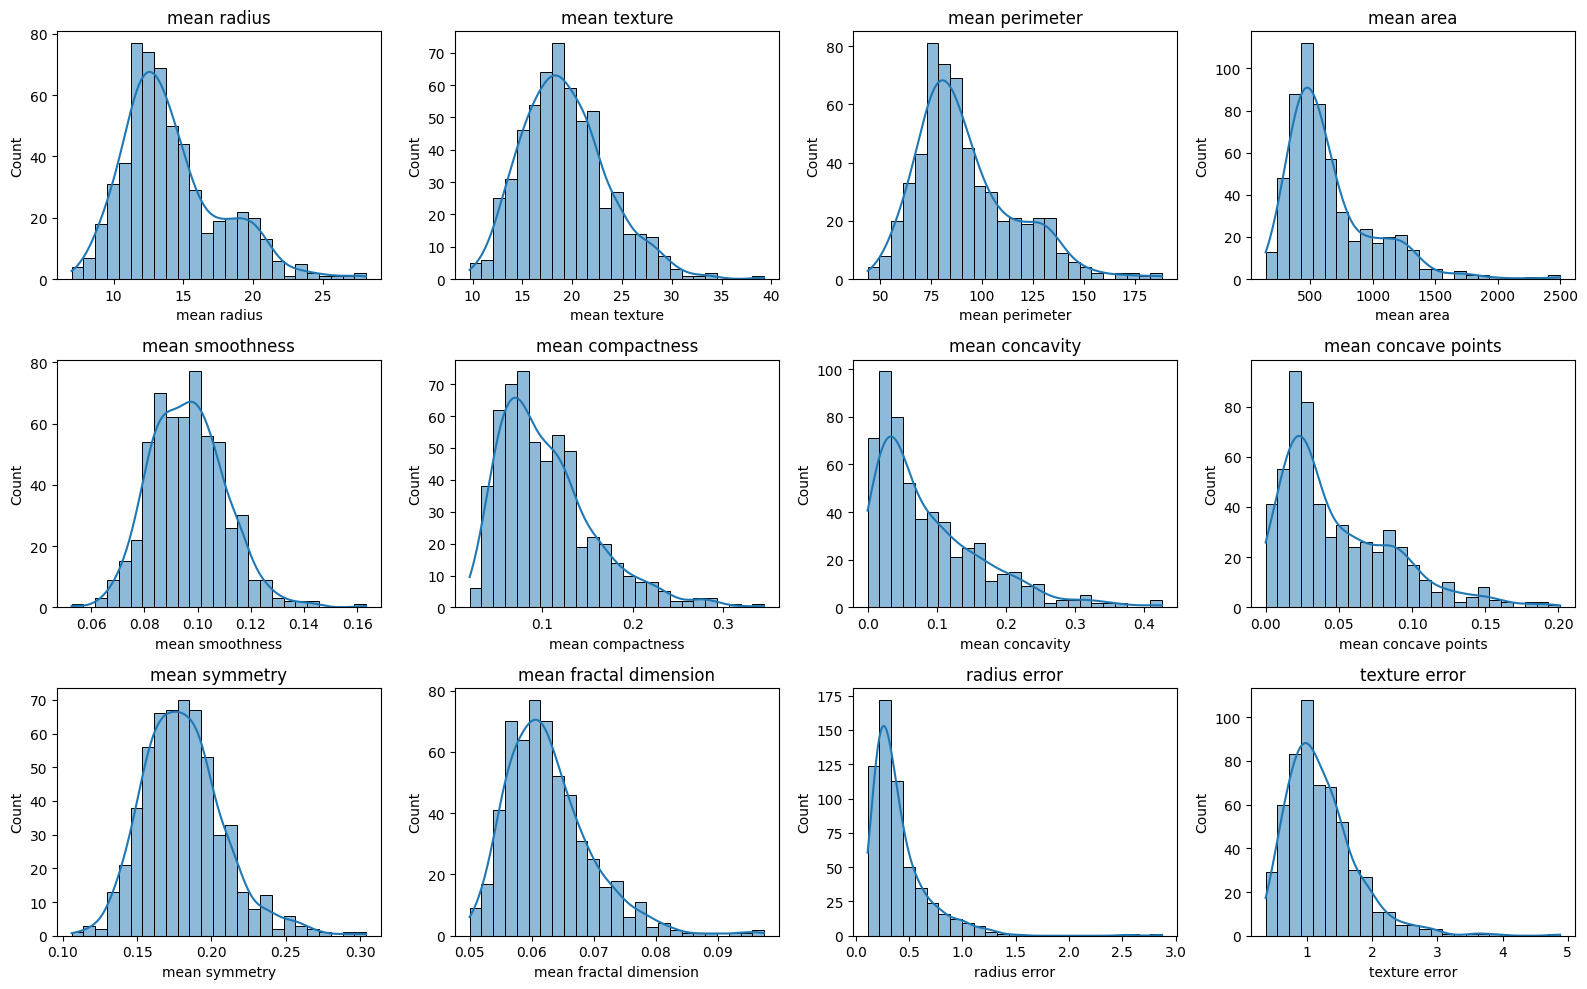

In [6]:
num_cols = df.columns.drop("target")

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(16, 10))
axes = axes.flatten()

for ax, col in zip(axes, num_cols[:12]):
    sns.histplot(data=df, x=col, bins=25, kde=True, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

**Exercici 6**

- Esculli tres variables i descrigui el seu histograma (forma, presència de valors extrems, simetria/asimetria).

MEAN RADIUS: Observem que abans ens haviem equivocat veient-ho com una gaussiana ja que realment son dues sumades que semblen representar dos grups de població diferents.

MEAN SYMMETRY: Aquí sí que ens trobem amb una gaussiana bastant perfecta.

RADIUS ERROR: Es tracta d'una variabla Laplaciana

- Expliqueu, amb paraules, per què la mitjana i la desviació estàndard poden ser poc representatives si la distribució és molt asimètrica o amb outliers.

Poden ser molt poc significatives en els casos on no tenim distribucions gaussianes perquè no ens diuen gaire cosa i també ens poden confondre en casos com el de mean radius perquè realment tenim bastants outliers que acaben sent com un segon grup.



### 4.4. Box Plots per visualitzar la dispersió


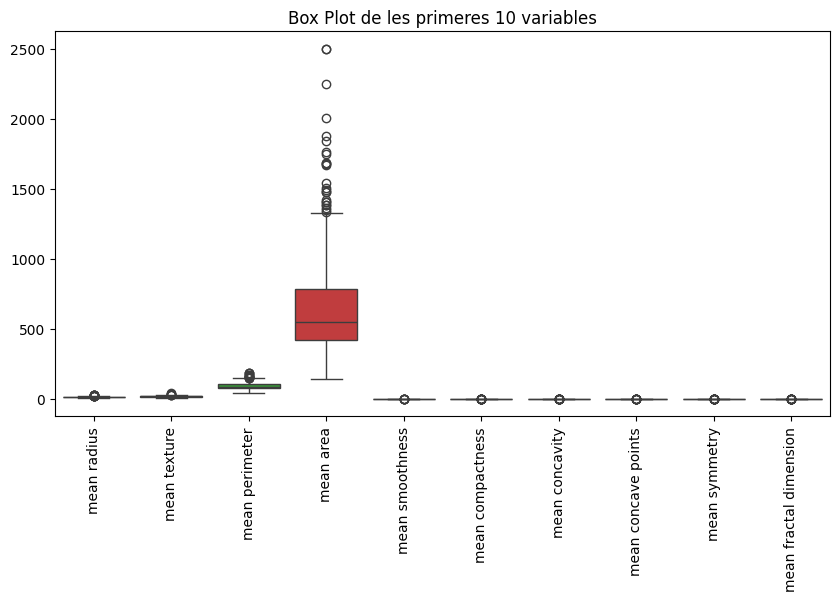

In [7]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[num_cols[:10]])
plt.xticks(rotation=90)
plt.title('Box Plot de les primeres 10 variables')
plt.show()

**Exercici 7**

- Esculli dues variables i descrigui el que veu al box plot: posició de la mediana, llargada de la caixa (rang interquartílic) i existència de punts atípics.

MEAN PERIMETER: Trobem una distribució molt comprimida degut a que mean area acapara molt espai del gràfic, amb els percentils pràcticament solapats. podem veure que el percentil 50% es troba situat als 200 aproximadament però amb molts outliers per sobre. 

MEAN AREA: Observem que el percentil 50% es troba situat a 500. La variança veiem que no es simetrica, observem que hi ha menys entre el percentil 25% i el 50% que no entre el 50 i el 75%. Observem molts outliers per sobre del 75%, que ens poden fer intuir el que hem vist abans, que hi ha dos grups de població diferent. Si haguéssim d'estandaritzar, ho tindriem molt difícil perquè ens ho espatllaries. 

- Com pot ajudar aquesta representació a detectar variables amb escales molt diferents o amb molts outliers?

Ens pot ajudar per veure que hi ha molts outliers que per sobre de totes les variables, que ens poden fer pensar el tema dels dos grups de població. 

### 4.5. Dependència de les variables amb la classe (EDA supervisat)


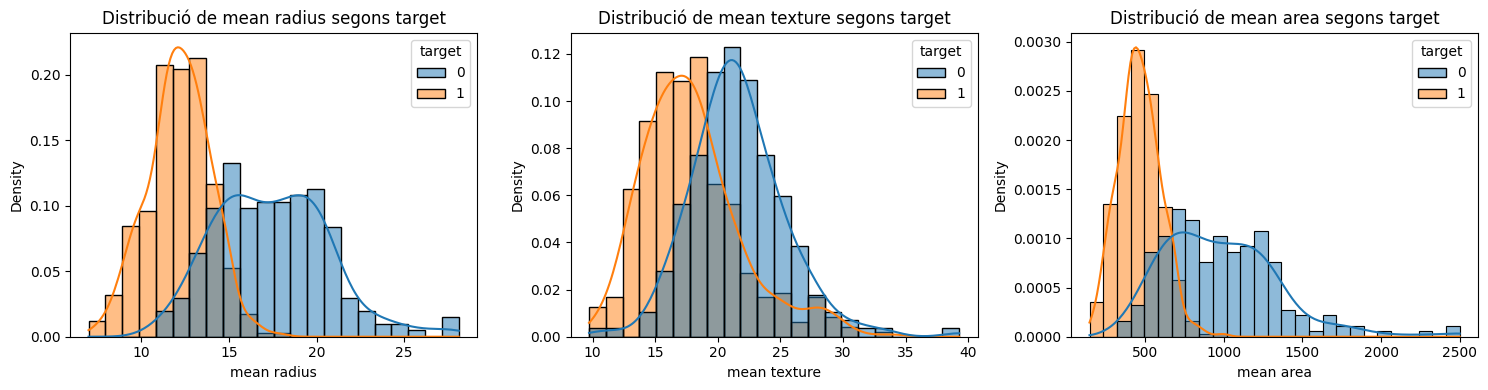

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
selected = ["mean radius", "mean texture", "mean area"]

for ax, col in zip(axes, selected):
    sns.histplot(data=df, x=col, hue="target", kde=True, ax=ax,
                 stat="density", common_norm=False)
    ax.set_title(f"Distribució de {col} segons target")

plt.tight_layout()
plt.show()

**Exercici 8**

- Per cadascuna de les tres variables seleccionades, descrigui breument les diferències entre tumors malignes i benignes.

0/ Maligne, 1/ Benigne

MEAN RADIUS: Notem que la distribució segons un tumor maligne és comporta com una doble Gaussiana o esquena de Camell. En canvi, la distribució per un tumor benigne es comporta com una Gaussiana.

MEAN TEXTURE: Observem que ambdos casos es comporten de manera bastant semblant entre ells i fidels a una Gaussiana, encara que podem notar que la distribució de tumor Maligne té algun valor una mica superior.

MEAN AREA: Passa molt semblant al primer gràfic a diferencia de que la magnitud és més petita,del ordre de 10 vegades.

- Pot identificar alguna variable que, només mirant el gràfic, sembli especialment discriminativa entre maligne i benigne?

Podriem dir que veritablement totes, encara que si hem de escollir una com la que MÉS en quedem amb la de la segona gràfica, MEAN TEXTURE. Diem que totes poden ser discriminatives de bona forma ja que podem implementar una fronter de decisió molt clara entre ambdues distribucions.



## 5. Relacions entre variables i correlació

### 5.1. Matriu de correlació


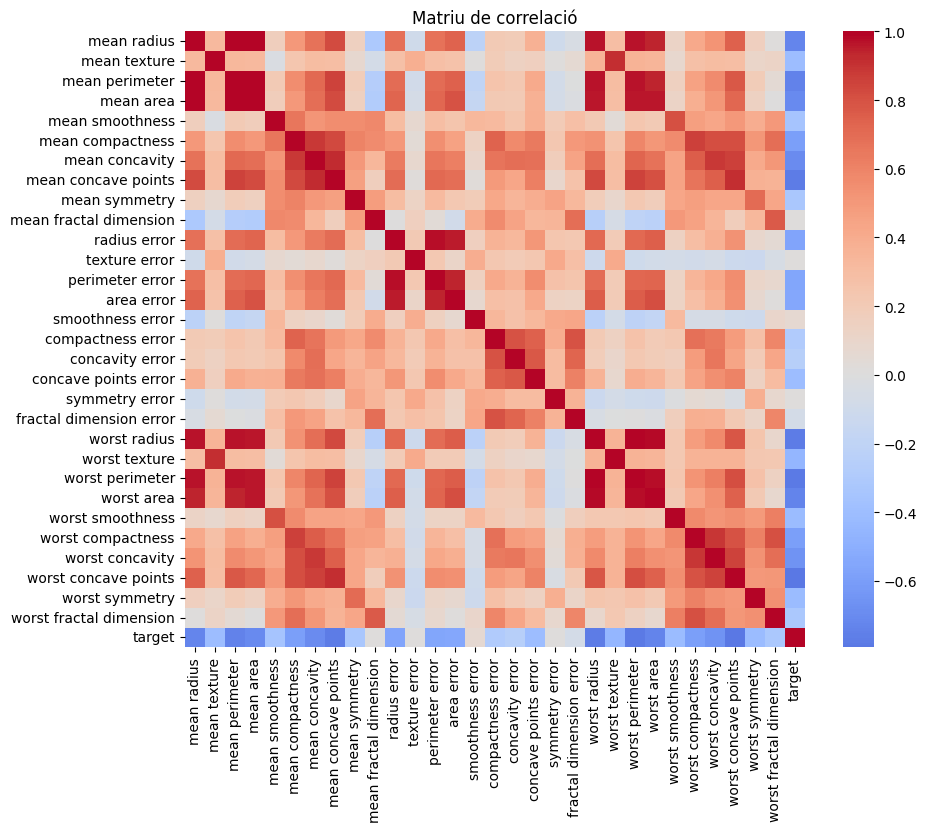

In [9]:
corr_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title('Matriu de correlació')
plt.show()

Ens interessa especialment la correlació de cada característica amb la variable `target` (diagnòstic).


In [10]:
corr_with_target = corr_matrix["target"].sort_values(ascending=False)
corr_with_target

target                     1.000000
smoothness error           0.067016
mean fractal dimension     0.012838
texture error              0.008303
symmetry error             0.006522
fractal dimension error   -0.077972
concavity error           -0.253730
compactness error         -0.292999
worst fractal dimension   -0.323872
mean symmetry             -0.330499
mean smoothness           -0.358560
concave points error      -0.408042
mean texture              -0.415185
worst symmetry            -0.416294
worst smoothness          -0.421465
worst texture             -0.456903
area error                -0.548236
perimeter error           -0.556141
radius error              -0.567134
worst compactness         -0.590998
mean compactness          -0.596534
worst concavity           -0.659610
mean concavity            -0.696360
mean area                 -0.708984
mean radius               -0.730029
worst area                -0.733825
mean perimeter            -0.742636
worst radius              -0

**Exercici 9**

- Identifiqueu les tres variables amb correlació més positiva amb `target` (recordar: 1 = benigne). Quin significat clínic pot tenir que aquestes variables tinguin correlació positiva amb la benignitat?

Les tres variables són: mean fractal dimension, texture error i smoothness error. Pues que si aquestes variables aumenten target també ho farà i per tant serà més probable que sigui benigne. 

- Identifiqueu també les tres variables amb correlació més negativa amb `target`. Què indica això respecte al risc de malignitat?

Les tres variables són: mean concave points, worst perimeter, worst concave points, quan aquestes variables augmentin, target disimnuirà i per tant serà més probable que sigui maligne. 


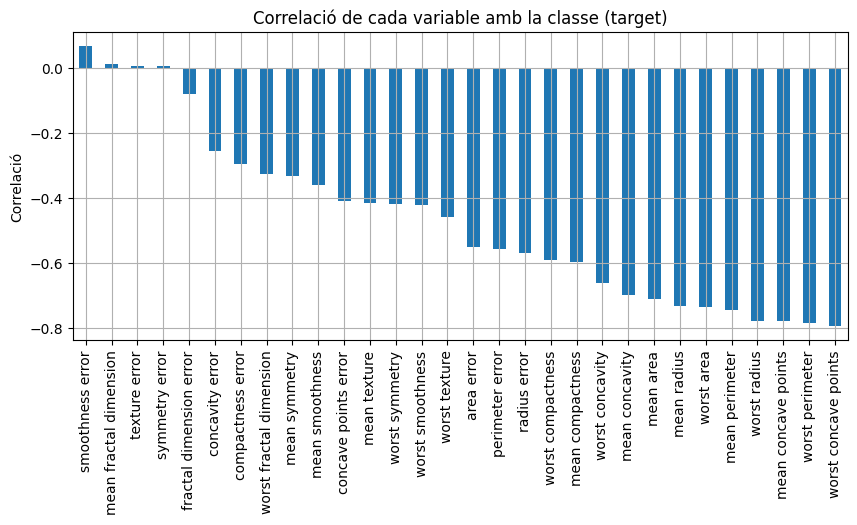

In [11]:
plt.figure(figsize=(10, 4))
corr_with_target[1:].plot.bar()
plt.title('Correlació de cada variable amb la classe (target)')
plt.ylabel('Correlació')
plt.grid(True)
plt.show()

**Exercici 10**

- Escrigui un paràgraf donant una explicació qualitativa de per què algunes variables poden estar positivament correlacionades amb `target` i altres negativament, en funció del seu significat (radi, àrea, textura, etc.).
- A partir d’aquesta figura, proposi una combinació lineal qualitativa (signes dels coeficients) per definir una "puntuació de risc" (puntuació alta = més probabilitat de malignitat).


Smoothnes error i mean fractal dimension, està correlada positivament amb target ja que quan tinguem el tumor amb més suavitat, aleshores serà més possible que sigui benigne. En canvi les variables worst concave points, worst perimeter, mean concave points, worst radius, mean perimeter, worst area, mean radius, mean area, mean concavity, worst concavity són les variables amb major correlació negativa, per tant, quan augmenten els valors que prenen, la probabilitat de maligne augmenta. 
Les variables que surten molt negatives, haurien de ser les que afecten més negativament a tenir un tumor benigne.  


## 6. Preparació per a Machine Learning

### 6.1. Partició entrenament / test


In [12]:
from sklearn.model_selection import train_test_split

X_features = df.drop(columns=["target"])
y_target = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_target,
    test_size=0.2,
    random_state=42,
    stratify=y_target
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (455, 30)
X_test shape: (114, 30)
y_train shape: (455,)
y_test shape: (114,)


**Exercici 11**

- Expliqueu en un paràgraf per què és necessari dividir el conjunt de dades en entrenament i test.

Sempre hem de dividir el conjunt de dades en entrenament i test per poder fer que el model aprengui de forma correcta les caracteristiques importants que ens interessen. Les dades d'entrenament son les que "enseñen" al model i las de test són amb las que el provem. Si no fessim la distinció el model no ens donaria un resultat real al provar-ho, ja que li passariem dades amb las que s'ha entrenat, fins i tot aprendria patrons del soroll que farian mal bé el model.


### 6.2. Estandardització de les característiques


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Valors abans d'estandaritzar")
pd.DataFrame(X_train, columns=X_train.columns).describe().round(1).iloc[1:]

Valors abans d'estandaritzar


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
mean,14.1,19.2,91.6,648.5,0.1,0.1,0.1,0.0,0.2,0.1,...,16.2,25.6,106.6,869.0,0.1,0.3,0.3,0.1,0.3,0.1
std,3.5,4.4,24.1,344.9,0.0,0.1,0.1,0.0,0.0,0.0,...,4.8,6.2,33.2,552.9,0.0,0.2,0.2,0.1,0.1,0.0
min,7.0,9.7,43.8,143.5,0.1,0.0,0.0,0.0,0.1,0.0,...,7.9,12.0,50.4,185.2,0.1,0.0,0.0,0.0,0.2,0.1
25%,11.6,16.0,74.7,415.6,0.1,0.1,0.0,0.0,0.2,0.1,...,13.0,21.1,83.7,513.9,0.1,0.1,0.1,0.1,0.2,0.1
50%,13.3,18.8,86.0,541.8,0.1,0.1,0.1,0.0,0.2,0.1,...,14.9,25.4,97.6,683.4,0.1,0.2,0.2,0.1,0.3,0.1
75%,15.7,21.7,103.7,770.0,0.1,0.1,0.1,0.1,0.2,0.1,...,18.6,29.4,125.0,1033.5,0.1,0.3,0.4,0.2,0.3,0.1
max,28.1,39.3,188.5,2499.0,0.1,0.3,0.4,0.2,0.3,0.1,...,33.1,49.5,229.3,3432.0,0.2,1.1,1.3,0.3,0.7,0.2


In [14]:
print("Valors després d'estandaritzar")
pd.DataFrame(X_train_scaled, columns=X_train.columns).describe().round(1).iloc[1:]

Valors després d'estandaritzar


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
mean,-0.0,0.0,-0.0,-0.0,0.0,-0.0,-0.0,0.0,-0.0,0.0,...,0.0,-0.0,-0.0,0.0,0.0,-0.0,0.0,-0.0,-0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
min,-2.0,-2.2,-2.0,-1.5,-2.5,-1.6,-1.1,-1.2,-2.7,-1.8,...,-1.7,-2.2,-1.7,-1.2,-2.7,-1.4,-1.3,-1.7,-2.1,-1.6
25%,-0.7,-0.7,-0.7,-0.7,-0.7,-0.8,-0.7,-0.7,-0.7,-0.7,...,-0.7,-0.7,-0.7,-0.6,-0.7,-0.7,-0.8,-0.8,-0.6,-0.7
50%,-0.2,-0.1,-0.2,-0.3,-0.0,-0.2,-0.4,-0.4,-0.1,-0.2,...,-0.3,-0.0,-0.3,-0.3,-0.0,-0.3,-0.2,-0.3,-0.1,-0.2
75%,0.5,0.6,0.5,0.4,0.6,0.5,0.5,0.7,0.5,0.5,...,0.5,0.6,0.6,0.3,0.6,0.5,0.5,0.7,0.5,0.4
max,4.0,4.6,4.0,5.4,3.6,4.5,4.1,3.9,4.4,4.8,...,3.6,3.8,3.7,4.6,3.8,5.0,4.5,2.7,5.8,6.7


**Exercici 12**

- Expliqui breument (un parell de línies) la diferència entre les taules "abans d’estandaritzar" i "després d’estandaritzar" pel que fa a mitjana, desviació estàndard i rang.

Abans d'estandaritzar cada variable té la seva propia mitjana, desviació estàndard i rang. Després d'estandaritzar la mitjana passa a ser 0, la desviació estandard es 1 i el rang va de 0 a 5.

- Per què és especialment important estandarditzar quan s’utilitzen mètodes basats en distàncies o hiperplans (p. ex. regressió logística, Lasso, k-means)?

En aquests mètodes és important estandaritzar per poder calcular bé les distanciés/hiperplans. Si no ho fem cada variable té una magnitud, cosa que pot fer que no totes tinguin la mateixa aportació pel nostre model.


## 7. Model de classificació: Random Forest


In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    oob_score=True
)

model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
print(f"Precisió (accuracy) en test: {acc*100:.2f} %")
print(f"OOB score aproximat: {model.oob_score_*100:.2f} %")

Precisió (accuracy) en test: 95.61 %
OOB score aproximat: 96.04 %


**Excercici 13.**
* Expliqui de forma qualitativa perque la precició i el OOB son semblants.

Perquè quan reservem un 30% per cada iteració que fem i comprobem al final haurem tingut moltes de tests diferents i en conjunt aquestes bases de tests diferents, acabaran comportant-se com una de test diferent separada. 

* Expliqui en un parragraf quina utilitat pot tenir aquesta propietat desde el punt de vista de la persona que prepara el sistema d' aprenentatge automàtic.

Aquesta propietat ens podria servir per utilitzar el 100% de la base de dades per entrenar el nostre model i seguir obtenint els resultats sense fer "trampes" ja que com hem comprobat a dalt, donen resultats molt semblants. 


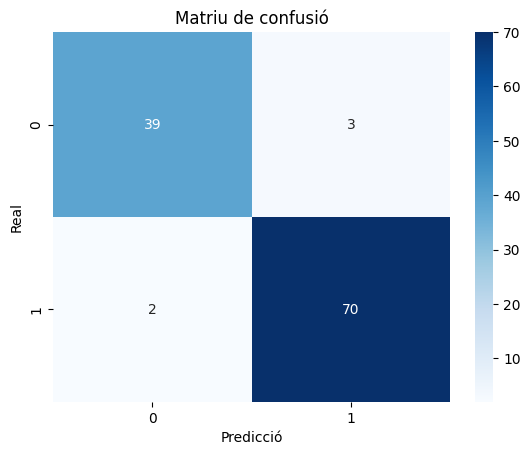

              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [16]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriu de confusió')
plt.xlabel('Predicció')
plt.ylabel('Real')
plt.show()

print(classification_report(y_test, y_pred))

**Exercici 14**

- Expliqueu en un paràgraf què ens indica la matriu de confusió: quins errors són més crítics en aquest context (falsos positius o falsos negatius) i per què.
- Comenteu la diferència entre **accuracy**, **precision**, **recall** i **f1-score** en aquest problema mèdic.

La matriu de confusió ens indica que obtenim molt bons resultats en línies generals. Només obtenim 5 casos de 114 on ens equivoquem, 2 per predir 0 quan és 1 i 3 per predir 0 quan és 1. En aquest cas, el pitjor cas és el fals positiu, que ens prediu que es tracta d'un tumor benigne però realment és maligne, cosa que ens farà diagnosticar erróneament a gent que podria seguir un tractament que podria millorar el diagnostic. 


## 8. Importància de variables (Random Forest)


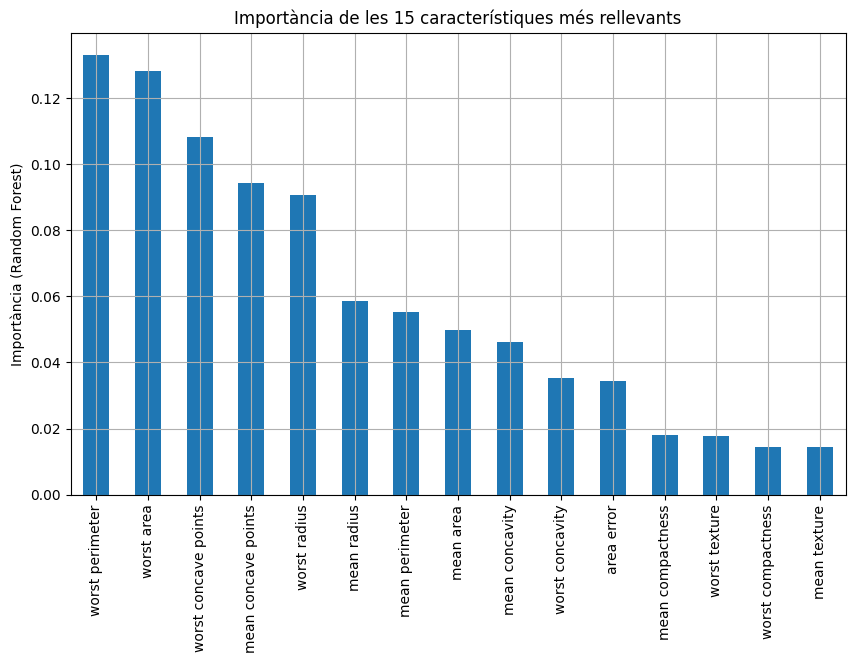

In [17]:
importances = model.feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(15).plot.bar()
plt.title('Importància de les 15 característiques més rellevants')
plt.ylabel('Importància (Random Forest)')
plt.grid(True)
plt.show()

**Exercici 15**

- Escrigui un paràgraf comparant la importància de les variables (segons Random Forest) amb la correlació amb `target`. Hi ha coincidències? Hi ha alguna sorpresa?
- Proposi una explicació geomètrica de la importància de variables: penseu en com els arbres tallen l’espai de característiques i en quines dimensions fan més "talls".

Les variables més importants son: worst perimeter, worst area, worst concave points, worst radius, mean radius i mean perimeter. Aquestes variables coincideixen molt amb les trobades a dalt quan hem calculat les correlacions. 

Les que tenien dues poblacions gaussianes, encertaran perque quan es relacionin amb altres variables amb característiques semblants, la separació serà millor i ens permetrà encertar la majoria dels casos.




## 9. Informe Final i Recomanacions


**Informe Final i Recomanacions**

Redactar un informe final on es relacioni:

- La informació obtinguda amb l’EDA (distribució de les variables, correlacions, diferències entre maligne i benigne).
- Els resultats obtinguts pel model de Machine Learning (matriu de confusió, mètriques, importància de variables).
- Recomanacions sobre:
  - Quines variables semblen més rellevants per al diagnòstic.
  - Possibles millores del model (ajust d’hiperparàmetres, altres classificadors, calibratge de probabilitats).
  - Precaucions ètiques i clíniques: la decisió mèdica no ha de dependre únicament del model.

L'objectiu d'aquest informe és classificar tumors de mama com a bons (1) o dolents(0) utilitzant la base de dades Breast Cancer Wisconsin, que conté 30 variables com la compactesa, el perímetre o la textura. Comencem amb l'EDA, on veiem que tenim 569 mostres sense valors nuls i un més de tipus 1 que de tipus 0(63% benignes vs 37% malignes). Veiem que la majoria de variables no presenten gaussianitat i són asimètriques. Observem que variables relacionades amb la mida i la concavitat presenten distribucions asimètriques amb molts outliers i estan fortament correlacionades amb el tips de tumor. Amb variables com mean_radius o mean_texture veiem que ens aparèixen dues distribucions separades pel tipus 1 i pel tipus 0, de manera que fent un scatter plot podriem arribar a veure que podem distingir molt bé només amb aquests casos. 

Utilitzem el dataset per entrenar un model de Random Forest perquè, juntament amb la tècnica de bagging, reduint la variància i evitant el sobreajustament d'un sol arbre de decisió. A més, comprobem que fer servir aixó, ens permet estimar l'error mitjançant OOB sense necessitat estricta d'un set de validació extern, de manera que podriem arribar a utilitzar el 100% del conjunt de dades per entrenar.

Un cop entrenat, la importància de les variables confirma l'EDA: els factors determinants són el worst concave points, el worst perimeter i el worst radius. En conclusió, el model aconsegueix una gran precisió basant-se principalment en la irregularitat i la mida dels tumors, aconseguit na tassa d'encert molt alta i poc percentatge de casos on no detectem la malaltia i realment està present, tot i això, podriem intentar calibrar els llindars de manera que reduissim encara més els casos on estimem tumor benigne i realment fos maligne.
